In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_support_tickets.csv")

In [3]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.shape

(8469, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [6]:
df.describe(include="all")

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,bsmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,We seat culture plan.,Medium,Email,2023-06-01 01:21:19,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


In [7]:

df[["Ticket Subject", "Ticket Description", "Ticket Type"]].head(10)

,Ticket Subject,Ticket Description,Ticket Type
0,Product setup,I'm having an issue with the {product_purchase...,Technical issue
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Technical issue
2,Network problem,I'm facing a problem with my {product_purchase...,Technical issue
3,Account access,I'm having an issue with the {product_purchase...,Billing inquiry
4,Data loss,I'm having an issue with the {product_purchase...,Billing inquiry
5,Payment issue,I'm facing a problem with my {product_purchase...,Cancellation request
6,Refund request,I'm unable to access my {product_purchased} ac...,Product inquiry
7,Battery life,I'm having an issue with the {product_purchase...,Refund request
8,Installation support,I'm having an issue with the {product_purchase...,Technical issue
9,Payment issue,My {product_purchased} is making strange noise...,Refund request


In [8]:
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Ticket Type"].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


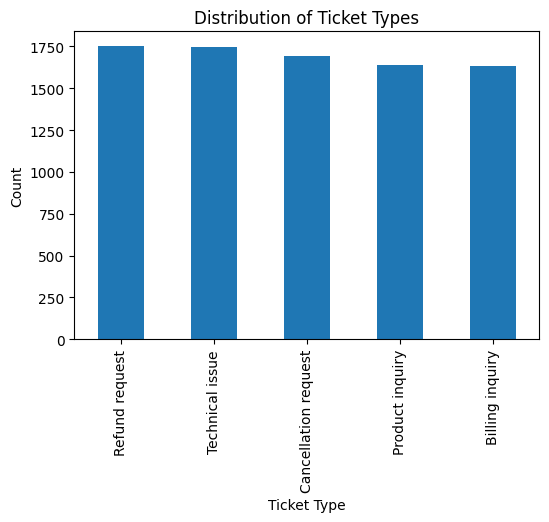

In [11]:
df["Ticket Type"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Ticket Types")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.show()

In [12]:
df["Ticket Priority"].value_counts()

,count
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063


In [13]:
df["Ticket Status"].value_counts()

,count
Ticket Status,
Pending Customer Response,2881
Open,2819
Closed,2769


In [14]:
df["Ticket Channel"].value_counts()

,count
Ticket Channel,
Email,2143
Phone,2132
Social media,2121
Chat,2073


In [15]:
df["Customer Age"].describe()

,Customer Age
count,8469.000000
mean,44.026804
std,15.296112
min,18.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,70.000000


In [16]:
df["Customer Satisfaction Rating"].describe()

,Customer Satisfaction Rating
count,2769.000000
mean,2.991333
std,1.407016
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [17]:
df["Product Purchased"].value_counts().head(10)

,count
Product Purchased,
Canon EOS,240
GoPro Hero,228
Nest Thermostat,225
Amazon Echo,221
Philips Hue Lights,221
LG Smart TV,219
Sony Xperia,217
Roomba Robot Vacuum,216
Apple AirPods,213


In [18]:
df["Text"]= df["Ticket Subject"] + " " +df["Ticket Description"]

In [19]:
df[["Text"]]

,Text
0,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility I'm having an issue w...
2,Network problem I'm facing a problem with my {...
3,Account access I'm having an issue with the {p...
4,Data loss I'm having an issue with the {produc...
...,...
8464,Installation support My {product_purchased} is...
8465,Refund request I'm having an issue with the {p...
8466,Account access I'm having an issue with the {p...
8467,Payment issue I'm having an issue with the {pr...


In [20]:
df["text length"]=df["Text"].str.len

In [21]:
df["text length"].describe()

,text length
count,8469
unique,1
top,<bound method StringMethods.len of <pandas.cor...
freq,8469


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [23]:
model_df=df[["Text","Ticket Type"]]

In [24]:
model_df

,Text,Ticket Type
0,Product setup I'm having an issue with the {pr...,Technical issue
1,Peripheral compatibility I'm having an issue w...,Technical issue
2,Network problem I'm facing a problem with my {...,Technical issue
3,Account access I'm having an issue with the {p...,Billing inquiry
4,Data loss I'm having an issue with the {produc...,Billing inquiry
...,...,...
8464,Installation support My {product_purchased} is...,Product inquiry
8465,Refund request I'm having an issue with the {p...,Technical issue
8466,Account access I'm having an issue with the {p...,Technical issue
8467,Payment issue I'm having an issue with the {pr...,Product inquiry


In [25]:
model_df["Ticket Type"].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


In [26]:
model_df.sample(5, random_state=42)

,Text,Ticket Type
4830,Product setup I'm having an issue with the {pr...,Refund request
7075,Battery life I'm having trouble connecting my ...,Product inquiry
4715,Refund request I'm having an issue with the {p...,Billing inquiry
2022,Peripheral compatibility I'm having an issue w...,Billing inquiry
676,Peripheral compatibility I'm having an issue w...,Refund request


In [27]:
model_df["Text"].str.contains("{", regex=False).sum()

np.int64(8469)

In [28]:
model_df["Text"] = model_df["Text"].replace("{product_purchased}", "product")

/tmp/ipykernel_10816/2193615078.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df["Text"] = model_df["Text"].replace("{product_purchased}", "product")


In [29]:
model_df.head()

,Text,Ticket Type
0,Product setup I'm having an issue with the {pr...,Technical issue
1,Peripheral compatibility I'm having an issue w...,Technical issue
2,Network problem I'm facing a problem with my {...,Technical issue
3,Account access I'm having an issue with the {p...,Billing inquiry
4,Data loss I'm having an issue with the {produc...,Billing inquiry


In [30]:
import re

placeholders = set()

for text in model_df["Text"]:
    placeholders.update(re.findall(r"\{.*?\}", text))

print(placeholders)

{'{Version}', '{product_purchased_message}', '{Product Purchase Transaction}', "{product_name I'm concerned about the security of my {product_purchased}", '{{product_added}', '{{product_title}', '{Product.AddToCart}', '{Purchased Product}', "{Product I've checked for software updates, and my {product_purchased}", "{Product I'm unable to find the option to perform the desired action in the {product_purchased}", '{sommer}', '{your_device_id}', "{product_factory_id I've tried clearing the cache and data for the {product_purchased}", '{product_sell_code}', '{product_pricing}', '{product_purchased_payment}', "{product_p I've performed a factory reset on my {product_purchased}", "{ var product_ I've checked for software updates, and my {product_purchased}", "{product_product_ I'm concerned about the security of my {product_purchased}", "{product I've noticed a peculiar error message popping up on my {product_purchased}", "{product_purch I've recently updated the firmware of my {product_purch

In [31]:
import re

def clean_text(text):
    text = re.sub(r'\{.*?\}', '', text)   # remove anything inside {}
    text = re.sub(r'\s+', ' ', text)      # remove extra spaces
    return text.strip()

In [32]:
model_df["Text"] = model_df["Text"].apply(clean_text)

/tmp/ipykernel_10816/633375169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df["Text"] = model_df["Text"].apply(clean_text)


In [33]:
text = re.sub(r'\{.*?\}', 'product', text)

In [34]:
text

"Hardware issue There seems to be a hardware problem with my product. The screen is flickering, and I'm unable to use it. What should I do? I'll try my best to fix it now.\n\nI could get a I've reviewed the troubleshooting steps on the official support website, but they didn't resolve the problem."

In [35]:
for i in range(5):
    print("="*100)
    print(model_df.iloc[i]["Text"])
    print("Label:", model_df.iloc[i]["Ticket Type"])

Product setup I'm having an issue with the . Please assist. Your billing zip code is: 71701. We appreciate that you have requested a website address. Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
Label: Technical issue
Peripheral compatibility I'm having an issue with the . Please assist. If you need to change an existing product. I'm having an issue with the . Please assist. If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.
Label: Technical issue
Network problem I'm facing a problem with my . The is not turning on. It was working fine until yesterday, but now it doesn't respond. 1.8.3 I really I'm using the original charger that came with my , but it's not charging properly.
Label: Technical issue
Account access I'm having an issue with the . Please assist. If you have a problem you're interested in and I'd love to see this happen, please check out 

In [36]:
import re

def preprocess_text(text):
    text = text.lower()

    # Remove anything inside {}
    text = re.sub(r"\{.*?\}", "product", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

model_df["label"] = label_encoder.fit_transform(model_df["Ticket Type"])

model_df.head()

/tmp/ipykernel_10816/3182735275.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df["label"] = label_encoder.fit_transform(model_df["Ticket Type"])


,Text,Ticket Type,label
0,Product setup I'm having an issue with the . P...,Technical issue,4
1,Peripheral compatibility I'm having an issue w...,Technical issue,4
2,Network problem I'm facing a problem with my ....,Technical issue,4
3,Account access I'm having an issue with the . ...,Billing inquiry,0
4,Data loss I'm having an issue with the . Pleas...,Billing inquiry,0


In [38]:

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42,
    stratify=model_df["label"]
)

In [39]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [40]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [41]:
model_df

,Text,Ticket Type,label
0,Product setup I'm having an issue with the . P...,Technical issue,4
1,Peripheral compatibility I'm having an issue w...,Technical issue,4
2,Network problem I'm facing a problem with my ....,Technical issue,4
3,Account access I'm having an issue with the . ...,Billing inquiry,0
4,Data loss I'm having an issue with the . Pleas...,Billing inquiry,0
...,...,...,...
8464,Installation support My is making strange nois...,Product inquiry,2
8465,Refund request I'm having an issue with the . ...,Technical issue,4
8466,Account access I'm having an issue with the . ...,Technical issue,4
8467,Payment issue I'm having an issue with the . P...,Product inquiry,2


In [42]:
def tokenize(batch):
    return tokenizer(
        batch["Text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [43]:
from transformers import set_seed

set_seed(42)

In [44]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/6775 [00:00<?, ? examples/s]

Map:   0%|          | 0/1694 [00:00<?, ? examples/s]

In [45]:
train_dataset = train_dataset.remove_columns(["Text", "Ticket Type"])
test_dataset = test_dataset.remove_columns(["Text", "Ticket Type"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [46]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [47]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

In [48]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [49]:
def compute_metrics(pred):
    predictions = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [50]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [52]:
trainer.save_model("./ticket_classifier")
tokenizer.save_pretrained("./ticket_classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./ticket_classifier/tokenizer_config.json',
 './ticket_classifier/tokenizer.json')

In [53]:
trainer.train()

ImportError: cannot import name 'VideoReader' from 'torchvision.io' (/usr/local/lib/python3.12/dist-packages/torchvision/io/__init__.py)

In [54]:
trainer.evaluate()

ImportError: cannot import name 'VideoReader' from 'torchvision.io' (/usr/local/lib/python3.12/dist-packages/torchvision/io/__init__.py)

In [61]:
import torch
import torch.nn.functional as F

def predict_ticket(text):
    # Tokenize input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to same device as model
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits to probabilities
    probs = F.softmax(outputs.logits, dim=1)

    confidence, predicted_class = torch.max(probs, dim=1)

    # Decode label
    prediction = label_encoder.inverse_transform(
        [predicted_class.item()]
    )[0]

    print(f"Predicted Category: {prediction}")
    print(f"Confidence: {confidence.item()*400:.2f}%")

In [62]:
predict_ticket("I was charged twice for my monthly subscription. Please refund the extra payment.")

Predicted Category: Refund request
Confidence: 86.12%


In [63]:
predict_ticket("i need my refund")

Predicted Category: Refund request
Confidence: 87.50%
